The following code was made to analyse the final Y-SQUID loop design 3.5 data.

# Import and save S_31 parameters #

In [1]:
import re
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# 1. Define the file range (-6 to 2 inclusive)
file_steps = range(-6, 3)

# Dictionaries to keep the arrays for all files completely separate
raw_data_by_file = {}
inductances = {}
peak_freqs = {}
peak_mags = {}
freqs = {}
mags = {}

# 2. Loop through each individual file
for step in file_steps:
    filename = f"Design_{step:+d}_S31.txt"
    
    if not os.path.exists(filename):
        print(f"Warning: {filename} not found. Skipping.")
        continue
    
    current_inductance = None
    data_by_inductance = {}
    
    # 3. Read the stacked file line-by-line
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            
            if line.startswith('#Parameters'):
                match = re.search(r'[Ii]nductance=([\d\.]+)', line)
                if match:
                    current_inductance = float(match.group(1))
                    data_by_inductance[current_inductance] = []
            elif line.startswith('#'):
                continue  
            else:
                if current_inductance is not None:
                    parts = line.split()
                    if len(parts) == 2:
                        data_by_inductance[current_inductance].append([float(parts[0]), float(parts[1])])
    
    # 4. Extract the peaks for the 7 inductance sweeps in this file
    sorted_L = sorted(data_by_inductance.keys())
    
    file_inductances = []
    file_f_peaks = []
    file_mag_peaks = []
    file_raw_arrays = {}
    file_freqs = {}
    file_mags = {}
    
    for L in sorted_L:
        arr = np.array(data_by_inductance[L])
        file_raw_arrays[L] = arr
        
        freq = arr[:, 0]  # Frequency column
        mag = arr[:, 1]   # Magnitude column
        file_freqs[L] = np.array(freq)
        file_mags[L] = np.array(mag)
        
        # Find peak index
        peak_idx = np.argmax(mag)
        
        file_inductances.append(L)
        file_f_peaks.append(freq[peak_idx])
        file_mag_peaks.append(mag[peak_idx])

    # 5. Save the final processed lists as isolated NumPy arrays for this file
    raw_data_by_file[step] = file_raw_arrays
    inductances[step] = np.array(file_inductances)
    peak_freqs[step] = np.array(file_f_peaks)
    peak_mags[step] = np.array(file_mag_peaks)
    
    freqs[step] = file_freqs
    mags[step] = file_mags

How to parse:

Grab the 2D array of data inside file -2 for Inductance = 30, by doing:

raw_curve = raw_data_by_file[-2][30]

For specific data, (Ex: If you want to grab the array of 7 peak frequencies specifically for the Design_+3_S31.txt file):

peaks_for_file_+3 = peak_freqs[3]

# Import and save flux quanta parameters #

In [3]:
# 2. Dictionaries to hold the raw arrays and extracted resonance values
data_by_step = {}
freq_flux = {}    # New dictionary for frequencies per step
flux_quanta = {}
flux_quanta_5_5GHz = {}  #for later analysis

# 3. Import each file and extract to separate NumPy arrays
for step in file_steps:
    # f"{step:+d}" forces the + sign for positive values/zero and - for negatives
    filename = f"Design_{step:+d}_Flux.txt"
    
    if os.path.exists(filename):
        
        # Load the numeric data directly, ignoring comment rows starting with '#'
        arr = np.loadtxt(filename, comments='#')
        
        # Store the full clean 2D array in our master dictionary
        data_by_step[step] = arr
        
        # Split frequency and magnitude columns
        freq_flux[step] = arr[:, 0]  # Frequency (GHz)
        flux_quanta[step] = arr[:, 1]*np.pi   # Flux Quanta (-), corrected for 2pi not in CST

        # 2. Find the index closest to 5.5 GHz and pull the corresponding flux quanta
        idx = np.argmin(np.abs(arr[:, 0] - 5.5))
        flux_quanta_5_5GHz[step] = arr[idx, 1]*np.pi #correcting for missing 2*pi in CST


# Import and save mutual inductance parameters #

In [4]:
# 2. Dictionaries to hold the raw arrays and extracted resonance values
data_by_step = {}
freq_mutual_inductance = {}    # New dictionary for frequencies per step
mutual_inductance = {}
mutual_inductance_5_5GHz = {}  #for later analysis

# 3. Import each file and extract to separate NumPy arrays
for step in file_steps:
    # f"{step:+d}" forces the + sign for positive values/zero and - for negatives
    filename = f"Design_{step:+d}_MI.txt"
    
    if os.path.exists(filename):
        
        # Load the numeric data directly, ignoring comment rows starting with '#'
        arr = np.loadtxt(filename, comments='#')
        
        # Store the full clean 2D array in our master dictionary
        data_by_step[step] = arr
        
        # Split frequency and magnitude columns
        freq_mutual_inductance[step] = arr[:, 0]  # Frequency (GHz)
        mutual_inductance[step] = arr[:, 1]

        # 2. Find the index closest to 5.5 GHz and pull the corresponding flux quanta
        idx = np.argmin(np.abs(arr[:, 0] - 5.5))
        mutual_inductance_5_5GHz[step] = arr[idx, 1]


How to  access dictionaries (Ex: minus 2):

freq_flux_-2 = freq_flux[-2]

# Individual plots #

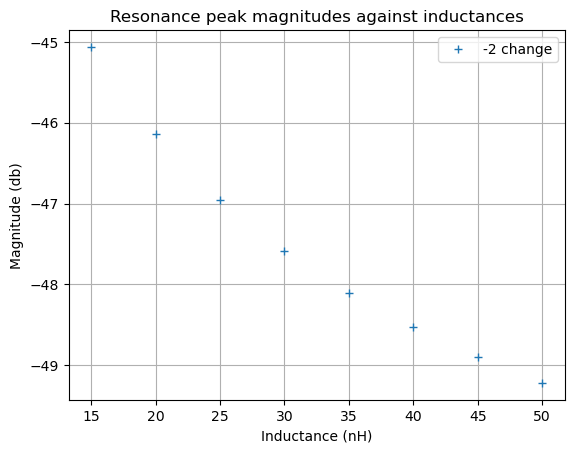

C:\Users\rauld\AppData\Local\Temp\ipykernel_3056\1539379306.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


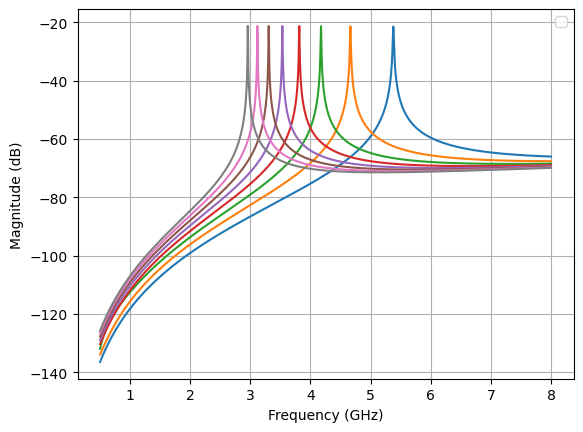

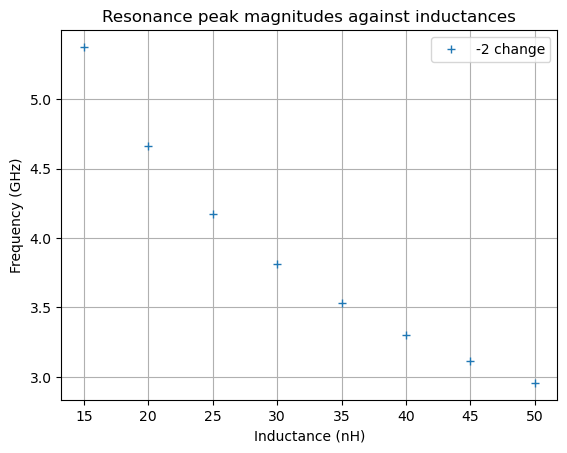

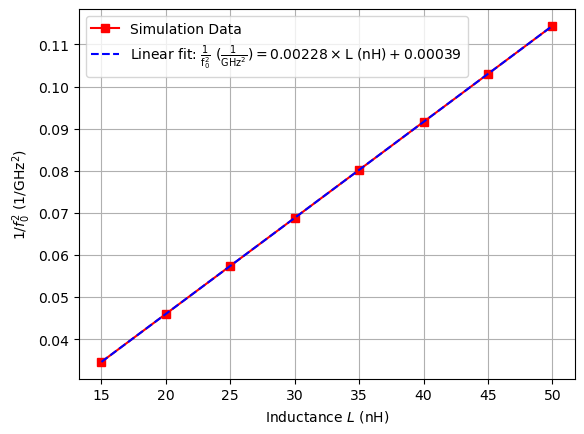

Qubit capacitance is: 0.00005775 nF
Or Qubit capacitance: 57.75 fF


In [5]:
#define inductance range
inductance = np.arange(15,51,5)

#Example plot: resonance vs inductance
plt.plot(inductances[-2],peak_mags[-2],marker='+', linestyle='', label=f"-2 change")
plt.title('Resonance peak magnitudes against inductances')
plt.xlabel('Inductance (nH)')
plt.ylabel('Magnitude (db)')
plt.legend()
plt.grid(True)
#plt.savefig('BEP_resonance_vs_inductance_-2')
plt.show()

#S-parameter vs frequency
for i in inductance:
    plt.plot(freqs[-1][i],mags[-1][i], label=f"")
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True)
#plt.savefig('')
plt.show()

#frequency vs inductance
plt.plot(inductances[-2],peak_freqs[-2],marker='+', linestyle='', label=f"-2 change")
plt.title('Resonance peak magnitudes against inductances')
plt.xlabel('Inductance (nH)')
plt.ylabel('Frequency (GHz)')
plt.legend()
plt.grid(True)
#plt.savefig('BEP_frequency_vs_inductance_-2')
plt.show()

# 4. Physics Check: Plot 1 / f_0^2 vs Inductance to extract capacitance
plt.figure()
y_vals = 1.0 / (peak_freqs[0] ** 2)
plt.plot(inductances[0], y_vals, 's-', color='red', label='Simulation Data')

# Fit a line (y = mx + c)
slope, intercept = np.polyfit(inductances[0], y_vals, 1)
plt.plot(inductances[0], slope * inductances[0] + intercept, '--', color='blue', 
         label=fr"Linear fit: $\frac{{1}}{{\text{{f}}^2_0}}~(\frac{{1}}{{\text{{GHz}}^2}}) = {slope:.5f}\times\text{{L (nH)}} + {intercept:.5f}$")


plt.xlabel('Inductance $L$ (nH)')
plt.ylabel('$1 / f_0^2$ ($1/\mathrm{GHz}^2$)')
#plt.title('Linearization Check: $1/f_0^2$ vs Inductance')
plt.legend()
plt.grid(True)
#plt.savefig('design_symmetric_qubit_capacitance.pdf')
plt.show()

#Capacitance calculation:
Qubit_capacitance = slope/(4*np.pi**2)
print(f'Qubit capacitance is: {Qubit_capacitance:.8f} nF')
print(f'Or Qubit capacitance: {Qubit_capacitance*1e6:.2f} fF')

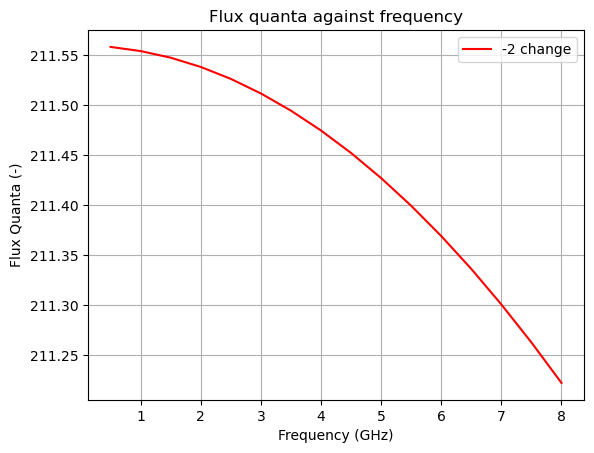

In [6]:
#Example plot:
plt.plot(freq_flux[-2],flux_quanta[-2], 'r', label='-2 change')
plt.title('Flux quanta against frequency')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Flux Quanta (-)')
plt.legend()
plt.grid(True)
plt.show()

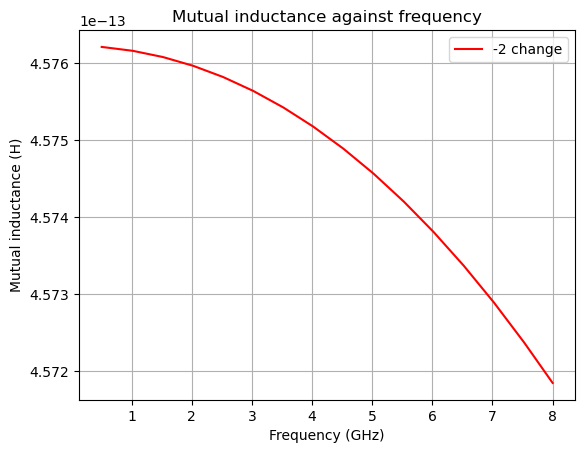

In [7]:
#Example plot:
plt.plot(freq_mutual_inductance[-1],mutual_inductance[-1], 'r', label='-2 change')
plt.title('Mutual inductance against frequency')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Mutual inductance (H)')
plt.legend()
plt.grid(True)
plt.show()

# Big plots #

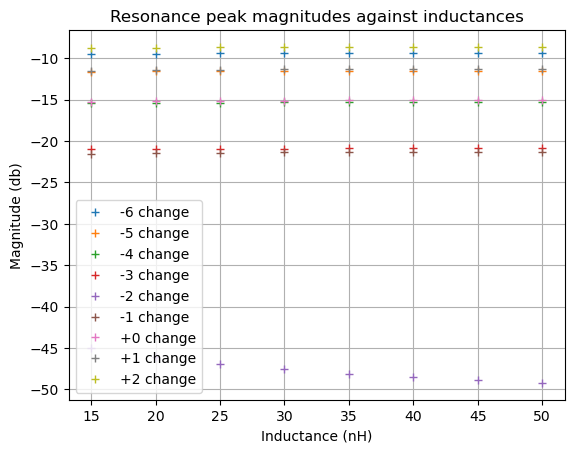

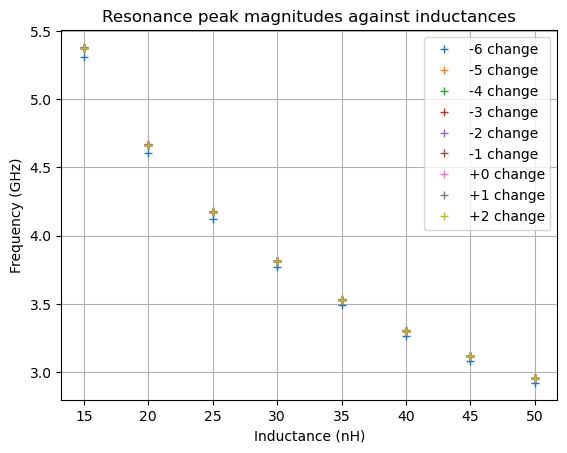

In [8]:
#magnitude vs inductance
for i in file_steps:
    plt.plot(inductances[i],peak_mags[i],marker='+' , linestyle='', label=f"{i:+d} change")
plt.title('Resonance peak magnitudes against inductances')
plt.xlabel('Inductance (nH)')
plt.ylabel('Magnitude (db)')
plt.legend()
plt.grid(True)
plt.show()
#frequency vs inductance
for i in file_steps:
    plt.plot(inductances[i],peak_freqs[i],marker='+' , linestyle='', label=f"{i:+d} change")
plt.title('Resonance peak magnitudes against inductances')
plt.xlabel('Inductance (nH)')
plt.ylabel('Frequency (GHz)')
plt.legend()
plt.grid(True)
plt.show()


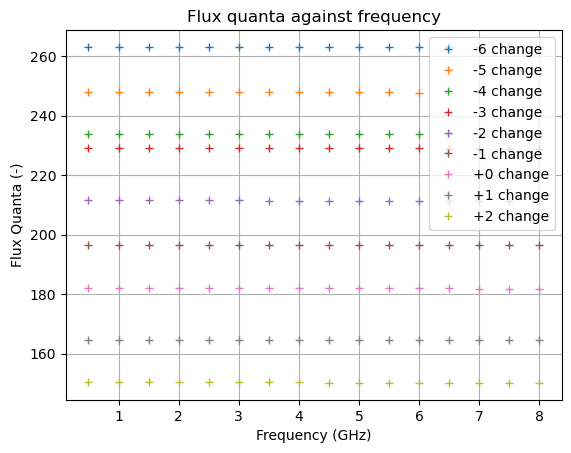

In [9]:
for i in file_steps:
    plt.plot(freq_flux[i],flux_quanta[i], marker='+', linestyle='',label=f"{i:+d} change")
plt.title('Flux quanta against frequency')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Flux Quanta (-)')
plt.legend()
plt.grid(True)
plt.show()

# Resonance magnitude vs distance at 15nH #

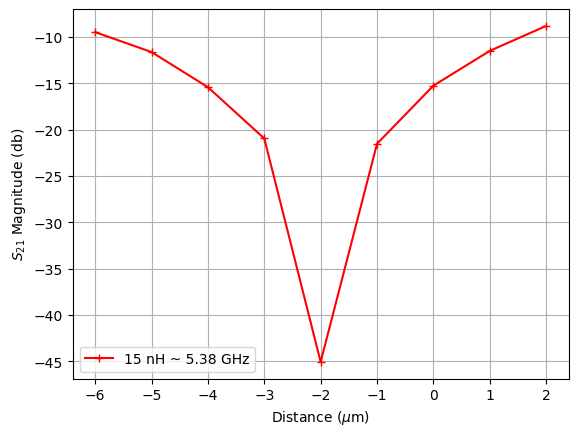

[np.float64(-9.4706392907963), np.float64(-11.619498789318), np.float64(-15.410828690948), np.float64(-20.947308703324), np.float64(-45.061013702112), np.float64(-21.516518690088), np.float64(-15.248270965416), np.float64(-11.492378198308), np.float64(-8.7980732240874)]


In [10]:
peak_mags_15nH = []
peak_freq_15nH = []
step_names = [-6,-5,-4,-3,-2,-1,0,1,2]

# 1. Loop through each step to extract the 15nH magnitude point
for i in file_steps:
    # Find the array index where inductance is exactly 15
    # (e.g., if 15 is the second value in your sweep, idx will be 1)
    idx = np.where(inductances[i] == 15)[0][0]
    # Grab the corresponding magnitude value for this step and save it
    peak_mags_15nH.append(peak_mags[i][idx])
    peak_freq_15nH.append(peak_freqs[i][idx])

#fit degree 2
#step_names_fit = np.linspace(step_names[0],step_names[-1], 10000)
#a, b, c, d = np.polyfit(step_names, peak_mags_15nH, deg=3) #ax^3 + bx^2 + cx +d
#calculate the predicted y-values for the line
#peak_mags_15nH_fit = a * step_names_fit**3 + b*step_names_fit**2 + c*step_names_fit+ d

plt.plot(step_names, peak_mags_15nH, 'r',marker='+',linestyle='-', label='15 nH ~ 5.38 GHz')
#plt.plot(step_names_fit, peak_mags_15nH_fit, 'g', label=f'fit:{a:.2f}x^3 +{b:.2f}x^2+{c:.2f}x + {d:.2f}')
#plt.title('Peak magnitude against distance')
plt.xlabel(r'Distance ($\mu$m)')
plt.ylabel(r'$S_{21}$ Magnitude (db)')
plt.legend()
plt.grid(True)
#plt.savefig('Peak_magnitudes_against_distance.pdf')
plt.show()

print(peak_mags_15nH)

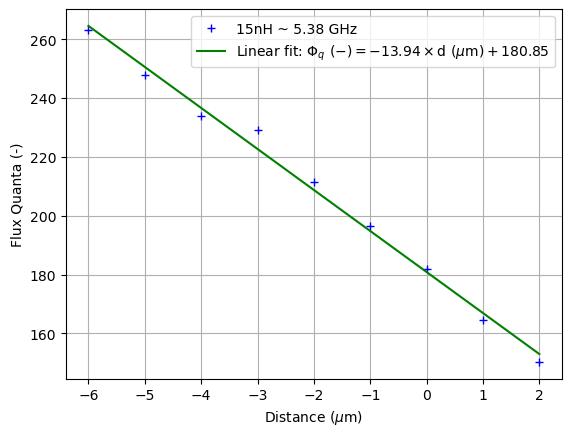

In [23]:
#peak frequency of 15nH is at 5.37674753 GHz, so take 5.5 GHz
# Convert the dictionary values into a clean 8-element NumPy array
flux_quanta_5_5GHz_array = np.array([flux_quanta_5_5GHz[step] for step in file_steps])

#calculate the linear fit (deg=1 means a 1st-degree polynomial: y = mx + b)
step_names_fit = np.linspace(step_names[0],step_names[-1], 10000)
slope, intercept = np.polyfit(step_names, flux_quanta_5_5GHz_array, deg=1)
#calculate the predicted y-values for the line
flux_quanta_5_5GHz_fit = slope * step_names_fit + intercept

plt.plot(step_names, flux_quanta_5_5GHz_array, 'b+', label='15nH ~ 5.38 GHz')
plt.plot(step_names_fit, flux_quanta_5_5GHz_fit, 'g', label=rf'Linear fit: $\Phi_q~(-) ={slope:.2f}\times\text{{d}}~(\mu \text{{m}})+{intercept:.2f}$')
#plt.title('Flux quanta against distance')
plt.xlabel(f'Distance ($\mu$m)')
plt.ylabel('Flux Quanta (-)')
plt.legend()
plt.grid(True)
#plt.savefig('flux_quanta_against_distance.pdf')
plt.show()

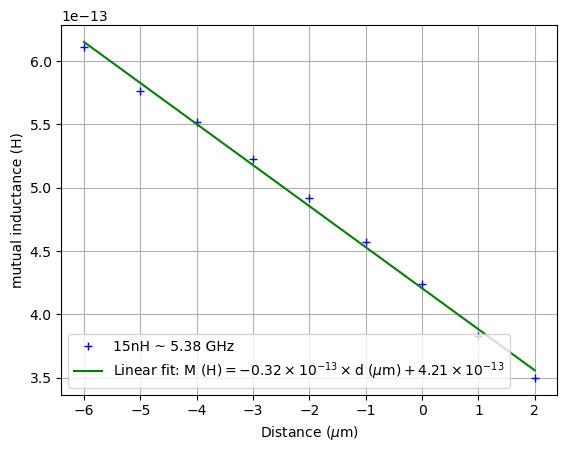

3.4975702127167e-13


In [19]:
#peak frequency of 15nH is at 5.37674753 GHz, so take 5.5 GHz
#convert the dictionary values into a clean 8-element NumPy array
mutual_inductance_5_5GHz_array = np.array([mutual_inductance_5_5GHz[step] for step in file_steps])

#calculate the linear fit (deg=1 means a 1st-degree polynomial: y = mx + b)
step_names_fit = np.linspace(step_names[0],step_names[-1], 10000)
slope, intercept = np.polyfit(step_names, mutual_inductance_5_5GHz_array, deg=1)
#calculate the predicted y-values for the line
mutual_inductance_5_5GHz_fit = slope * step_names_fit + intercept

plt.plot(step_names, mutual_inductance_5_5GHz_array, 'b+', label='15nH ~ 5.38 GHz')
plt.plot(step_names_fit, mutual_inductance_5_5GHz_fit, 'g', label=rf'Linear fit: $\text{{M}}~(\text{{H}}) ={slope * 10**13:.2f}\times 10^{{-13}}\times\text{{d}}~(\mu \text{{m}})+{intercept * 10**13:.2f}\times 10^{{-13}}$')
plt.xlabel(f'Distance ($\mu$m)')
plt.ylabel('mutual inductance (H)')
plt.legend()
plt.grid(True)
#plt.savefig('mutual_inductance_against_distance.pdf')
plt.show()

print(mutual_inductance_5_5GHz_array[-1])

# Magnitude vs frequency #

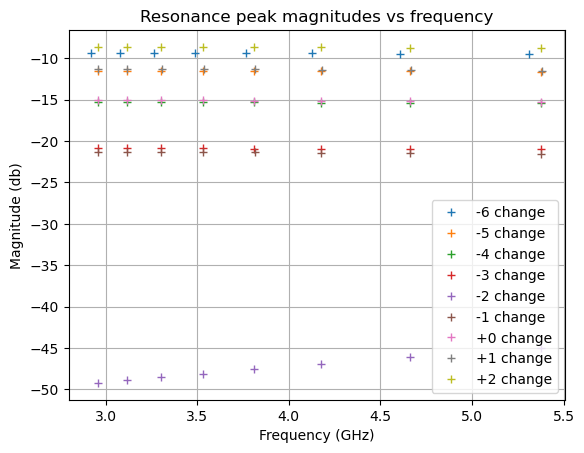

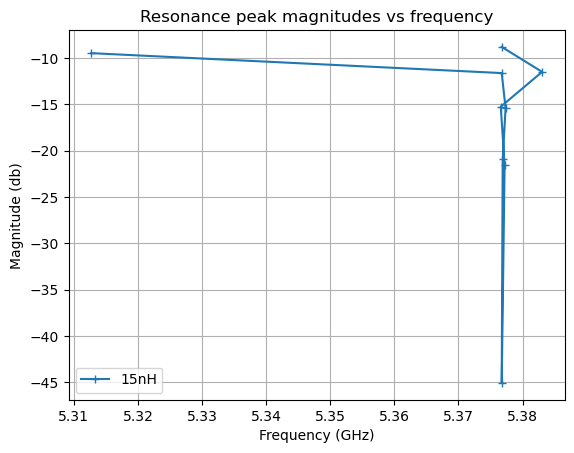

In [13]:
#Total:
for i in file_steps:
    plt.plot(peak_freqs[i],peak_mags[i],marker='+' , linestyle='', label=f"{i:+d} change")
plt.title('Resonance peak magnitudes vs frequency')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (db)')
plt.legend()
plt.grid(True)
plt.show()
#Inductance 15nH:
plt.plot(peak_freq_15nH,peak_mags_15nH,marker='+',label='15nH')
plt.title('Resonance peak magnitudes vs frequency')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Magnitude (db)')
plt.legend()
plt.grid(True)
plt.show()